# Imports

In [198]:
import matplotlib.pyplot as plt
import numpy as np
import ctypes

from numpy import dtype
from pandas.core.dtypes.cast import maybe_downcast_to_dtype

from rust_bridge import MLPRust,TaskMode

try:
    lib = ctypes.cdll.LoadLibrary('../lib_classification/target/release/lib_classification.dll')
except :
    print("ERROR : You must build the lib (into release) before using it")

## Classification

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [199]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
], dtype=np.float32)
Y = np.array([
      1,
      -1,
      -1
], dtype=np.float32)

#### CODE ADDED :

##### MODEL INITIALIZATION

In [200]:
mlp = MLPRust(
        layer_sizes=[2,1],
        learning_rate=0.01,
        task_mode=TaskMode.CLASSIFICATION,
    )

##### MODEL TRAINING

In [201]:
mlp.fit(X, Y, steps=1000)

##### MODEL PREDICTION

In [202]:
points_to_predict = []

for i in range(-10,41):
    for j in range(-10,41):
        points_to_predict.append((i/10,j/10))
points_to_predict = np.array(points_to_predict)

labels = []
colors = []

for p in points_to_predict:
    if mlp.predict_labels(p) == -1:
        labels.append(1.0)
        colors.append('lightblue')
    else:
        labels.append(-1.0)
        colors.append('pink')

#### PLOT CREATION

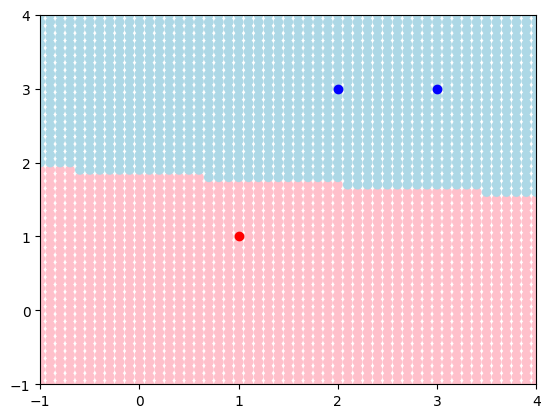

<Figure size 640x480 with 0 Axes>

In [203]:
plt.scatter(points_to_predict[:, 0], points_to_predict[:, 1], c=colors)

plt.scatter(X[0, 0], X[0, 1], color='red')
plt.scatter(X[1:3,0], X[1:3,1], color='blue')

plt.xlim(-1, 4)
plt.ylim(-1, 4)
plt.show()
plt.clf()

### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [204]:
X = np.concatenate(
    [
        np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])
    ], dtype=np.float32
    )
Y = np.concatenate(
    [
        np.ones((50,1), dtype=np.float32), np.ones((50,1),dtype=np.float32) * -1.0
    ]
    )

#### CODE ADDED :

##### MODEL INITIALIZATION

In [205]:
try :
    mlp.close()
except:
    pass

mlp = MLPRust(
        layer_sizes=[2,1],
        learning_rate=0.01,
        task_mode=TaskMode.CLASSIFICATION,
    )

##### MODEL TRAINING

In [206]:
mlp.fit(X, Y, steps=10000)

##### MODEL PREDICTION

In [207]:
points_to_predict = []

points_to_predict = []

for i in range(100):
    for j in range(100):
        points_to_predict.append((i/10,j/10))
points_to_predict = np.array(points_to_predict)

labels = []
colors = []

for p in points_to_predict:
    if mlp.predict_labels(p) == -1:
        labels.append(1.0)
        colors.append('pink')
    else:
        labels.append(-1.0)
        colors.append('lightblue')

#### PLOT CREATION

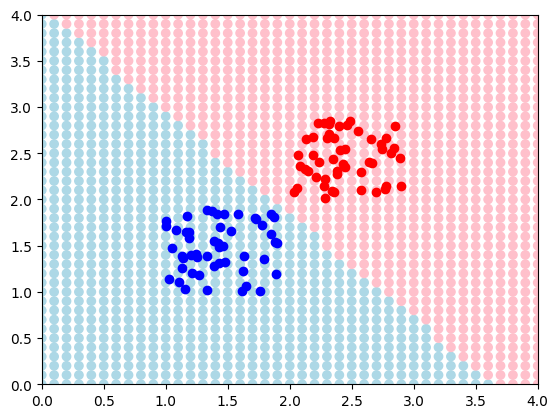

<Figure size 640x480 with 0 Axes>

In [208]:
plt.scatter(points_to_predict[:, 0], points_to_predict[:, 1], c=colors)

plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.show()
plt.clf()

### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

In [209]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

#### CODE ADDED :

##### MODEL INITIALIZATION

In [210]:
try :
    mlp.close()
except:
    pass

mlp = MLPRust(
        layer_sizes=[2,2,1],
        learning_rate=0.1,
        task_mode=TaskMode.CLASSIFICATION,
    )

##### MODEL TRAINING

In [211]:
mlp.fit(X, Y, steps=1_000_000)

##### MODEL PREDICTION

In [212]:
points_to_predict = []

for i in range(101):
    for j in range(101):
        points_to_predict.append((i/100.0,j/100.0))
points_to_predict = np.array(points_to_predict)

labels = []
colors = []

for p in points_to_predict:
    if mlp.predict_labels(p) == -1:
        labels.append(1.0)
        colors.append('pink')
    else:
        labels.append(-1.0)
        colors.append('lightblue')

#### PLOT CREATION

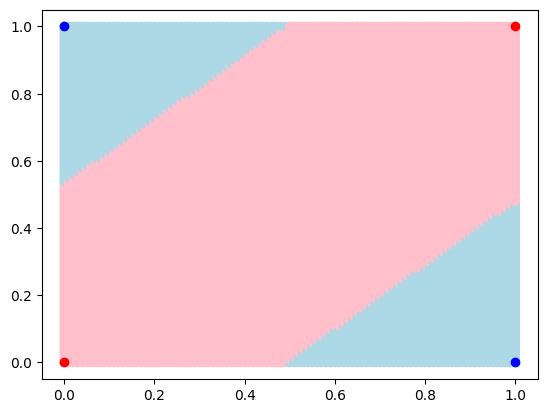

<Figure size 640x480 with 0 Axes>

In [213]:
plt.scatter(points_to_predict[:, 0], points_to_predict[:, 1], c=colors)

plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()

























































































### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

In [214]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

#### CODE ADDED :

##### MODEL INITIALIZATION

In [215]:
try :
    mlp.close()
except:
    pass

mlp = MLPRust(
        layer_sizes=[2,4,1],
        learning_rate=0.01,
        task_mode=TaskMode.CLASSIFICATION,
    )

##### MODEL TRAINING

In [216]:
mlp.fit(X, Y, steps=1_000_000)

##### MODEL PREDICTION

In [217]:
points_to_predict = []

for i in range(-100,100):
    for j in range(-100,100):
        points_to_predict.append((i/100,j/100))
points_to_predict = np.array(points_to_predict)

labels = []
colors = []

for p in points_to_predict:
    if mlp.predict_labels(p) == -1:
        labels.append(1.0)
        colors.append('pink')
    else:
        labels.append(-1.0)
        colors.append('lightblue')

#### PLOT CREATION

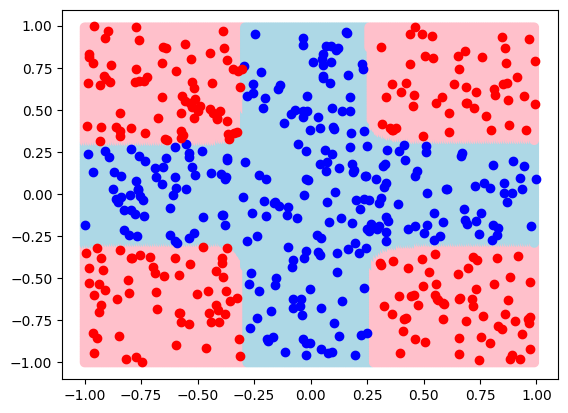

<Figure size 640x480 with 0 Axes>

In [218]:
plt.scatter(points_to_predict[:, 0], points_to_predict[:, 1], c=colors)

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK

In [219]:
X = (np.random.random((500, 2)) * 2.0 - 1.0).astype(np.float32)
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X]).astype(np.float32)

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

#### CODE ADDED :

##### MODEL INITIALIZATION

In [220]:
try :
    mlp.close()
except:
    pass

mlp = MLPRust(
        layer_sizes=[2,3],
        learning_rate=0.01,
        task_mode=TaskMode.CLASSIFICATION,
    )

##### MODEL TRAINING

In [221]:
mlp.fit(X, Y, steps=10000)

##### MODEL PREDICTION

In [222]:
points_to_predict = []

for i in range(-100,100):
    for j in range(-100,100):
        points_to_predict.append((i/100,j/100))
points_to_predict = np.array(points_to_predict)

labels = []
colors = []

test = set()

for p in points_to_predict:
    if (mlp.predict_labels(p)[0] == [1,-1,-1]).all():
        labels.append(1.0)
        colors.append('lightblue')
    elif (mlp.predict_labels(p)[0] == [-1,1,-1]).all():
        labels.append(0.0)
        colors.append('pink')
    else:
        labels.append(-1.0)
        colors.append('lightgreen')

#### PLOT CREATION

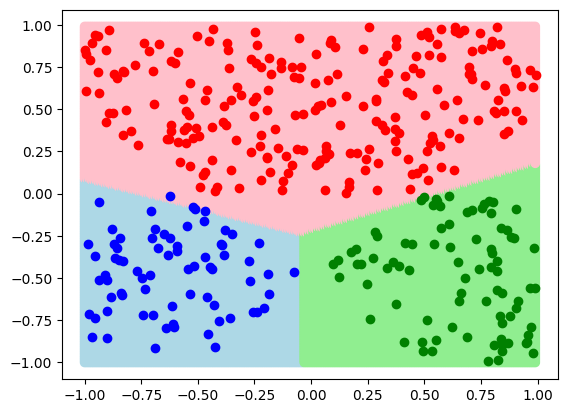

<Figure size 640x480 with 0 Axes>

In [223]:
plt.scatter(points_to_predict[:, 0], points_to_predict[:, 1], c=colors)

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

### Multi Cross :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): OK

In [224]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

#### CODE ADDED :

##### MODEL INITIALIZATION

In [225]:
try :
    mlp.close()
except:
    pass

mlp = MLPRust(
        layer_sizes=[2,49,49,3],
        learning_rate=0.001,
        task_mode=TaskMode.CLASSIFICATION,
    )

##### MODEL TRAINING

In [226]:
mlp.fit(X, Y, steps=1_000_000)

##### MODEL PREDICTION

In [227]:
points_to_predict = []

for i in range(-100,100):
    for j in range(-100,100):
        points_to_predict.append((i/100.0,j/100.0))
points_to_predict = np.array(points_to_predict)

labels = []
colors = []

for p in points_to_predict:
    if (mlp.predict_labels(p)[0] == [-1,-1,1]).all():
        labels.append(1.0)
        colors.append('lightgreen')
    elif (mlp.predict_labels(p)[0] == [-1,1,-1]).all():
        labels.append(0.0)
        colors.append('pink')
    elif (mlp.predict_labels(p)[0] == [1,-1,-1]).all():
        labels.append(-1.0)
        colors.append('lightblue')

#### PLOT CREATION

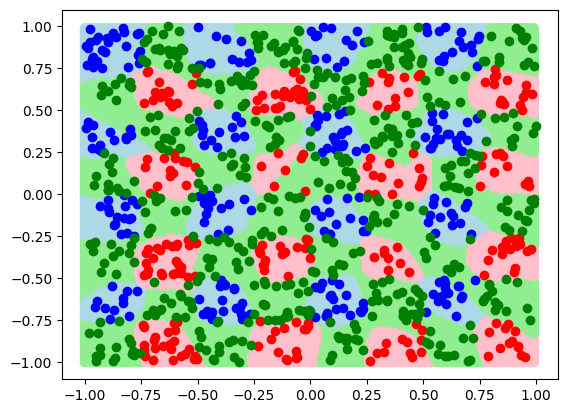

<Figure size 640x480 with 0 Axes>

In [228]:
plt.scatter(points_to_predict[:, 0], points_to_predict[:, 1], c=colors)

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

## Régression

### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK

In [229]:
X = np.array([
      [1],
      [2]
], dtype=np.float32)
Y = np.array([
      2,
      3
], dtype=np.float32)

#### CODE ADDED :

##### MODEL INITIALIZATION

In [230]:
try :
    mlp.close()
except:
    pass

mlp = MLPRust(
        layer_sizes=[1,1],
        learning_rate=0.001,
        task_mode=TaskMode.REGRESSION,
    )

##### MODEL TRAINING

In [231]:
mlp.fit(X, Y, steps=100_000)

##### MODEL PREDICTION

In [232]:
points_to_predict = []

for i in range(-10,20):
    points_to_predict.append((i/10.0))
points_to_predict = np.array(points_to_predict)

labels = []

predicted_points = []

for p in points_to_predict:
    predicted_points.append(mlp.predict(p))
predicted_points = np.array(predicted_points)

#### PLOT CREATION

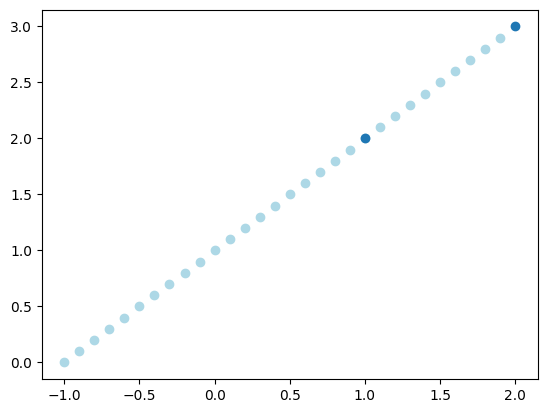

<Figure size 640x480 with 0 Axes>

In [233]:
plt.scatter(points_to_predict, predicted_points, c="lightblue")

plt.scatter(X,Y)
plt.show()
plt.clf()

### Non Linear Simple 2D :
        Linear Model    : OK
        MLP (1, ?, 1)   : OK

In [234]:
X = np.array([
      [1],
      [2],
      [3]
], dtype=np.float32)
Y = np.array([
      2,
      3,
      2.5
], dtype=np.float32)

#### CODE ADDED :

##### MODEL INITIALIZATION

In [235]:
try :
    mlp.close()
except:
    pass

mlp = MLPRust(
        layer_sizes=[1,3,1],
        learning_rate=0.001,
        task_mode=TaskMode.REGRESSION,
    )

##### MODEL TRAINING

In [236]:
mlp.fit(X, Y, steps=1_000_000)

##### MODEL PREDICTION

In [237]:
points_to_predict = []

for i in range(10,30):
    points_to_predict.append((i/10.0))
points_to_predict = np.array(points_to_predict)

labels = []

predicted_points = []

for p in points_to_predict:
    predicted_points.append(mlp.predict(p))
predicted_points = np.array(predicted_points)

#### PLOT CREATION

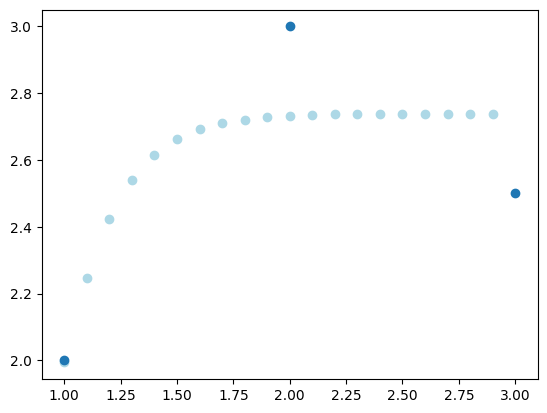

<Figure size 640x480 with 0 Axes>

In [238]:
plt.scatter(points_to_predict, predicted_points, c="lightblue")

plt.scatter(X,Y)
plt.show()
plt.clf()

### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [239]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
], dtype=np.float32)
Y = np.array([
      2,
      3,
      2.5
], dtype=np.float32)

#### CODE ADDED :

##### MODEL INITIALIZATION

In [240]:
try :
    mlp.close()
except:
    pass

mlp = MLPRust(
        layer_sizes=[2,1],
        learning_rate=0.001,
        task_mode=TaskMode.REGRESSION,
    )

##### MODEL TRAINING

In [241]:
mlp.fit(X, Y, steps=1_000_000)

##### MODEL PREDICTION

In [242]:
points_to_predict = []

for i in range(31):
    for j in range(31):
        points_to_predict.append((i/10.0,j/10.0))
points_to_predict = np.array(points_to_predict)

labels = []

predicted_points = []

for p in points_to_predict:
    predicted_points.append(mlp.predict(p))
predicted_points = np.array(predicted_points)

#### PLOT CREATION

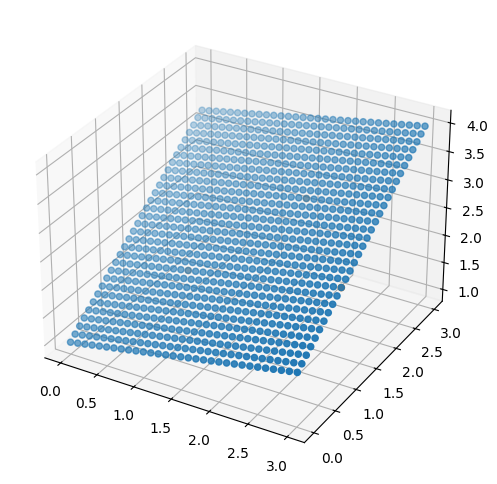

In [243]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")


ax.scatter(points_to_predict[:,0], points_to_predict[:,1], predicted_points[:,0])

ax.scatter(X[:,0], X[:,1], Y)

plt.show()

### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [244]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
], dtype=np.float32)
Y = np.array([
      1,
      2,
      3
], dtype=np.float32)

#### CODE ADDED :

##### MODEL INITIALIZATION

In [245]:
try :
    mlp.close()
except:
    pass

mlp = MLPRust(
        layer_sizes=[2,1],
        learning_rate=0.001,
        task_mode=TaskMode.REGRESSION,
    )

##### MODEL TRAINING

In [246]:
mlp.fit(X, Y, steps=1_000_000)

##### MODEL PREDICTION

In [247]:
points_to_predict = []

for i in range(31):
    for j in range(31):
        points_to_predict.append((i/10.0,j/10.0))
points_to_predict = np.array(points_to_predict)

labels = []

predicted_points = []

for p in points_to_predict:
    predicted_points.append(mlp.predict(p))
predicted_points = np.array(predicted_points)

#### PLOT CREATION

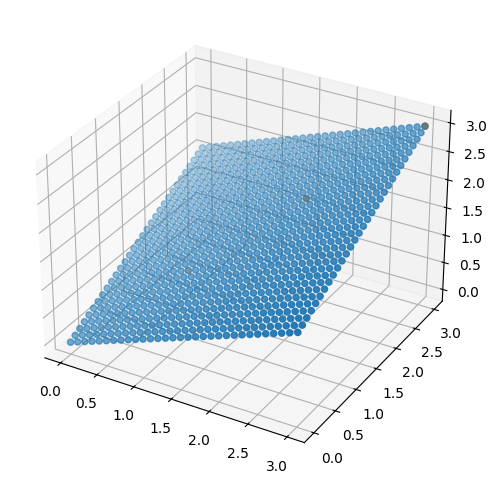

In [248]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(points_to_predict[:,0], points_to_predict[:,1], predicted_points[:,0])

ax.scatter(X[:,0], X[:,1], Y)


plt.show()

### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

In [249]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
], dtype=np.float32)
Y = np.array([
      2,
      1,
      -2,
      -1
], dtype=np.float32)

#### CODE ADDED :

##### MODEL INITIALIZATION

In [250]:
try :
    mlp.close()
except:
    pass

mlp = MLPRust(
        layer_sizes=[2,2,1],
        learning_rate=0.01,
        task_mode=TaskMode.REGRESSION,
    )

##### MODEL TRAINING

In [251]:
mlp.fit(X, Y, steps=1_000_000)

##### MODEL PREDICTION

In [252]:
points_to_predict = []

for i in range(11):
    for j in range(11):
        points_to_predict.append((i/10.0,j/10.0))
points_to_predict = np.array(points_to_predict)

labels = []

predicted_points = []

for p in points_to_predict:
    predicted_points.append(mlp.predict(p))
predicted_points = np.array(predicted_points)

#### PLOT CREATION

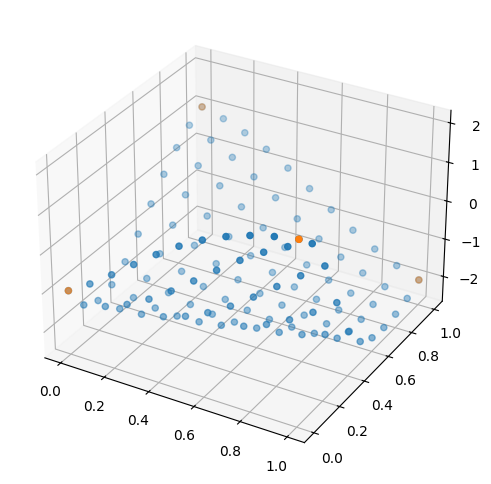

In [253]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(points_to_predict[:,0], points_to_predict[:,1], predicted_points[:,0])

ax.scatter(X[:,0], X[:,1], Y)


plt.show()